# MSE vs Binary Cross-Entropy (BCE)

Why classification uses **Binary Cross-Entropy** instead of **Mean Squared Error**, using a simple weather example.

$$\text{MSE} = (y - \hat{y})^2$$
$$\text{BCE} = -\big[\, y\log(\hat{y}) + (1-y)\log(1-\hat{y}) \,\big]$$

In [5]:
import numpy as np
import matplotlib.pyplot as plt


def mse(y, p):
    return (y - p) ** 2


def bce(y, p):
    eps = 1e-15  # avoid log(0)
    p = np.clip(p, eps, 1 - eps)
    return -(y * np.log(p) + (1 - y) * np.log(1 - p))


y = 1  # it actually rained
preds = [0.99, 0.80, 0.60, 0.50, 0.40, 0.30, 0.20,  0.10, 0.01]

print(f"{'Prediction':>10} | {'MSE':>8} | {'BCE':>8}")
print("-" * 34)
for p in preds:
    print(f"{p*100:>9.0f}% | {mse(y, p):>8.4f} | {bce(y, p):>8.3f}")

Prediction |      MSE |      BCE
----------------------------------
       99% |   0.0001 |    0.010
       80% |   0.0400 |    0.223
       60% |   0.1600 |    0.511
       50% |   0.2500 |    0.693
       40% |   0.3600 |    0.916
       30% |   0.4900 |    1.204
       20% |   0.6400 |    1.609
       10% |   0.8100 |    2.303
        1% |   0.9801 |    4.605


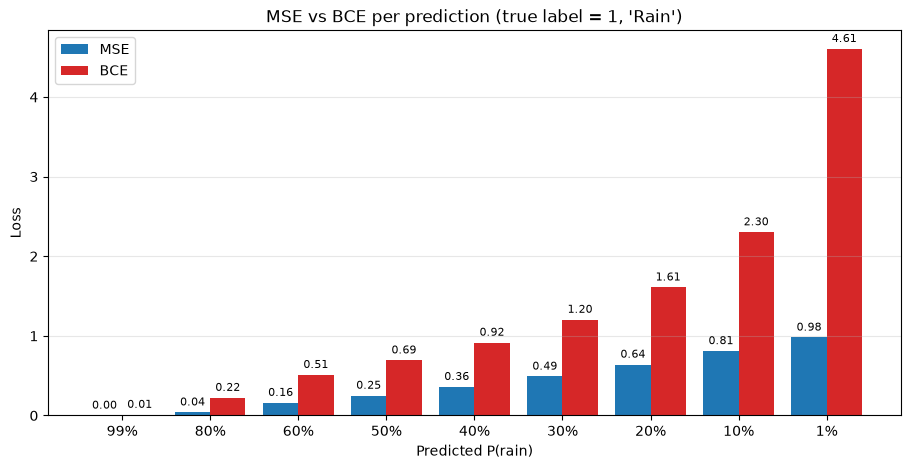

In [14]:
# Grouped bar chart: MSE vs BCE per prediction (true label = 1).
bar_preds = preds
labels = [f"{p*100:.0f}%" for p in bar_preds]
mse_vals = [mse(1, p) for p in bar_preds]
bce_vals = [bce(1, p) for p in bar_preds]

x = np.arange(len(bar_preds))
width = 0.4

plt.figure(figsize=(11, 5))
bars_mse = plt.bar(x - width / 2, mse_vals, width, label="MSE", color="tab:blue")
bars_bce = plt.bar(x + width / 2, bce_vals, width, label="BCE", color="tab:red")
plt.bar_label(bars_mse, fmt="%.2f", padding=3, fontsize=8)
plt.bar_label(bars_bce, fmt="%.2f", padding=3, fontsize=8)
plt.title("MSE vs BCE per prediction (true label = 1, 'Rain')")
plt.xlabel("Predicted P(rain)")
plt.ylabel("Loss")
plt.xticks(x, labels)
plt.legend()
plt.grid(True, axis="y", alpha=0.3)
plt.show()